# Churn Prediction — Exploratory Data Analysis
Analyse exploratoire du dataset Telco Churn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='husl')
plt.rcParams['figure.figsize'] = (12, 5)

In [2]:
import sys, os
sys.path.insert(0, '..')
from src.preprocess import load_data
df = load_data()
print(f'Shape: {df.shape}')
df.head()

[INFO] Données réelles non trouvées → génération synthétique.
[INFO] Dataset chargé : 5000 lignes, 17 colonnes
Shape: (5000, 17)


,customer_id,gender,senior_citizen,partner,dependents,tenure,phone_service,multiple_lines,internet_service,online_security,tech_support,contract,paperless_billing,payment_method,monthly_charges,total_charges,churn
0,C00000,Male,0,No,No,27,Yes,No,No,No internet service,No internet service,Month-to-month,No,Credit card (automatic),80.95,3165.32,No
1,C00001,Female,0,No,No,21,Yes,Yes,No,No,No internet service,Month-to-month,No,Credit card (automatic),36.75,7768.05,Yes
2,C00002,Male,0,No,Yes,15,Yes,No,No,No,No,Two year,No,Credit card (automatic),116.54,6283.81,No
3,C00003,Male,1,Yes,No,12,Yes,Yes,No,No,No internet service,Month-to-month,Yes,Credit card (automatic),97.61,6467.28,No
4,C00004,Male,0,Yes,No,61,Yes,No,DSL,No,Yes,Month-to-month,Yes,Bank transfer (automatic),96.89,4800.88,No


## 1. Vue d'ensemble

In [3]:
print('=== Types & Valeurs Manquantes ===')
info = pd.DataFrame({
    'dtype': df.dtypes,
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().sum() / len(df) * 100).round(2),
    'unique': df.nunique()
})
print(info)

=== Types & Valeurs Manquantes ===
                     dtype  null_count  null_pct  unique
customer_id         object           0       0.0    5000
gender              object           0       0.0       2
senior_citizen       int32           0       0.0       2
partner             object           0       0.0       2
dependents          object           0       0.0       2
tenure               int32           0       0.0      72
phone_service       object           0       0.0       2
multiple_lines      object           0       0.0       3
internet_service    object           0       0.0       3
online_security     object           0       0.0       3
tech_support        object           0       0.0       3
contract            object           0       0.0       3
paperless_billing   object           0       0.0       2
payment_method      object           0       0.0       4
monthly_charges    float64           0       0.0    3894
total_charges      float64           0       0.0    4

In [4]:
print(df.describe().T.to_string())

                  count         mean          std    min        25%       50%        75%      max
senior_citizen   5000.0     0.154400     0.361368   0.00     0.0000     0.000     0.0000     1.00
tenure           5000.0    35.321200    20.774108   0.00    17.0000    35.000    53.0000    71.00
monthly_charges  5000.0    67.962368    28.723283  18.01    43.0125    68.455    92.3400   117.98
total_charges    5000.0  4277.527550  2442.687399  18.07  2200.7525  4286.020  6414.3525  8498.04


## 2. Distribution du Churn (variable cible)

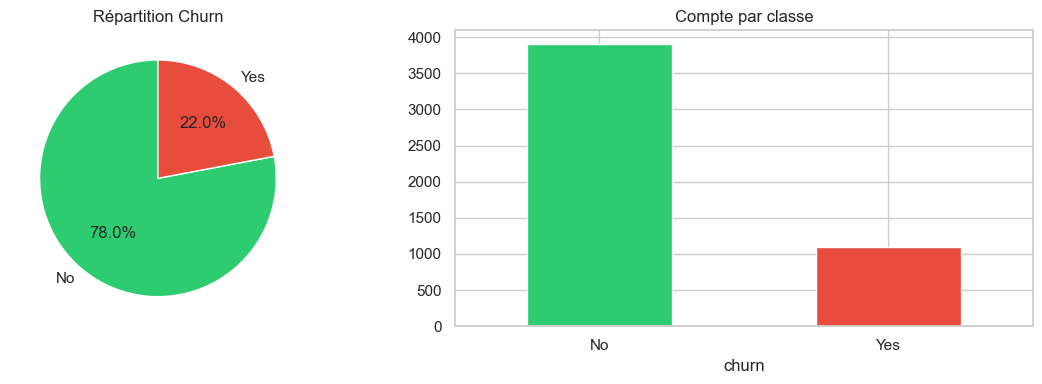

Taux de churn: 22.0%


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
churn_counts = df['churn'].value_counts()
axes[0].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
            colors=['#2ecc71','#e74c3c'], startangle=90)
axes[0].set_title('Répartition Churn')
churn_counts.plot(kind='bar', ax=axes[1], color=['#2ecc71','#e74c3c'])
axes[1].set_title('Compte par classe')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()
print(f'Taux de churn: {(df["churn"]=="Yes").mean():.1%}')

## 3. Variables Numériques

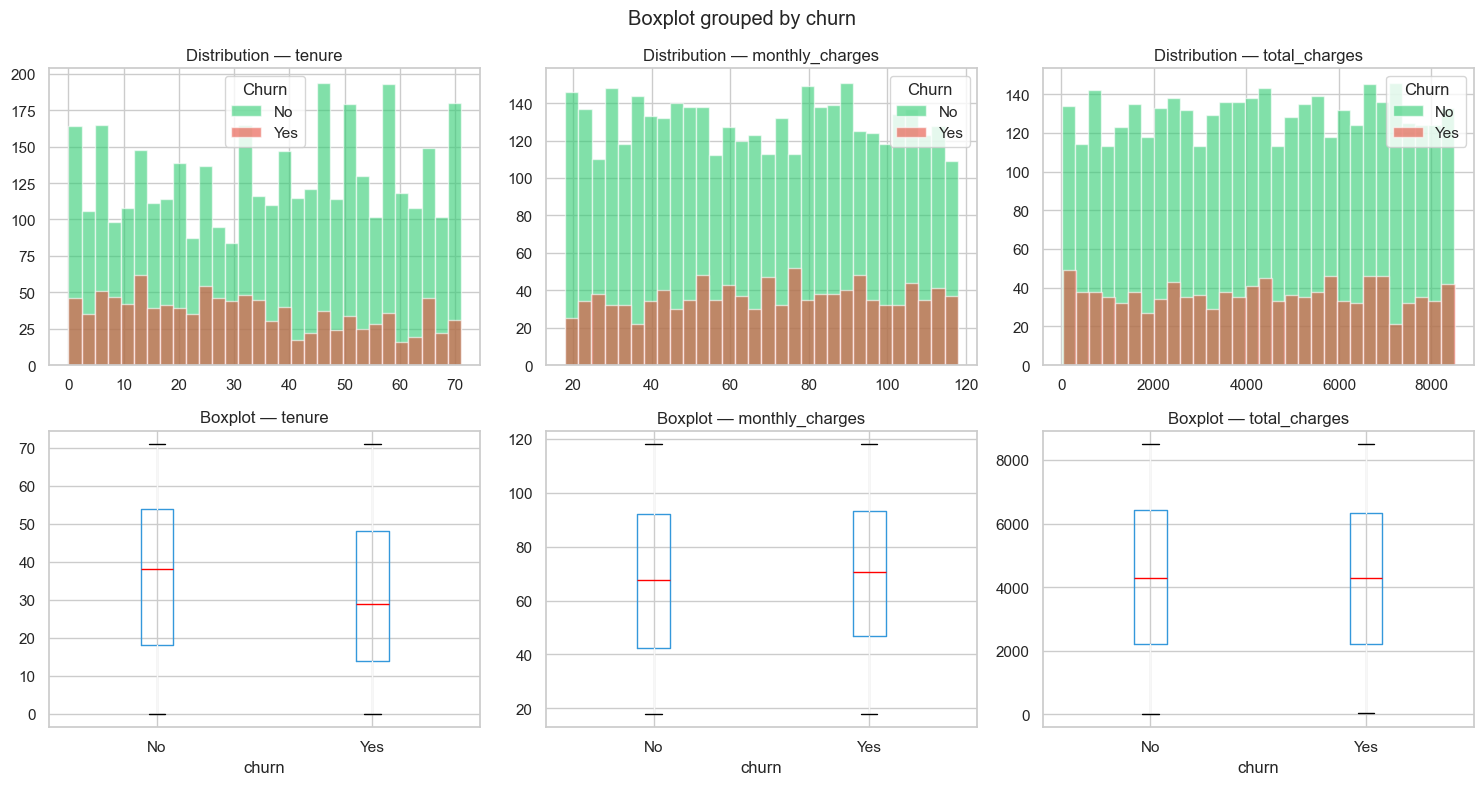

In [6]:
num_cols = ['tenure', 'monthly_charges', 'total_charges']
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(num_cols):
    df[col] = pd.to_numeric(df[col], errors='coerce')
    # Distribution
    for label, color in [('No','#2ecc71'),('Yes','#e74c3c')]:
        subset = df[df['churn']==label][col].dropna()
        axes[0,i].hist(subset, alpha=0.6, color=color, label=label, bins=30)
    axes[0,i].set_title(f'Distribution — {col}')
    axes[0,i].legend(title='Churn')
    # Boxplot
    df.boxplot(column=col, by='churn', ax=axes[1,i],
               boxprops=dict(color='#3498db'),
               medianprops=dict(color='red'))
    axes[1,i].set_title(f'Boxplot — {col}')
plt.tight_layout()
plt.show()

## 4. Variables Catégorielles vs Churn

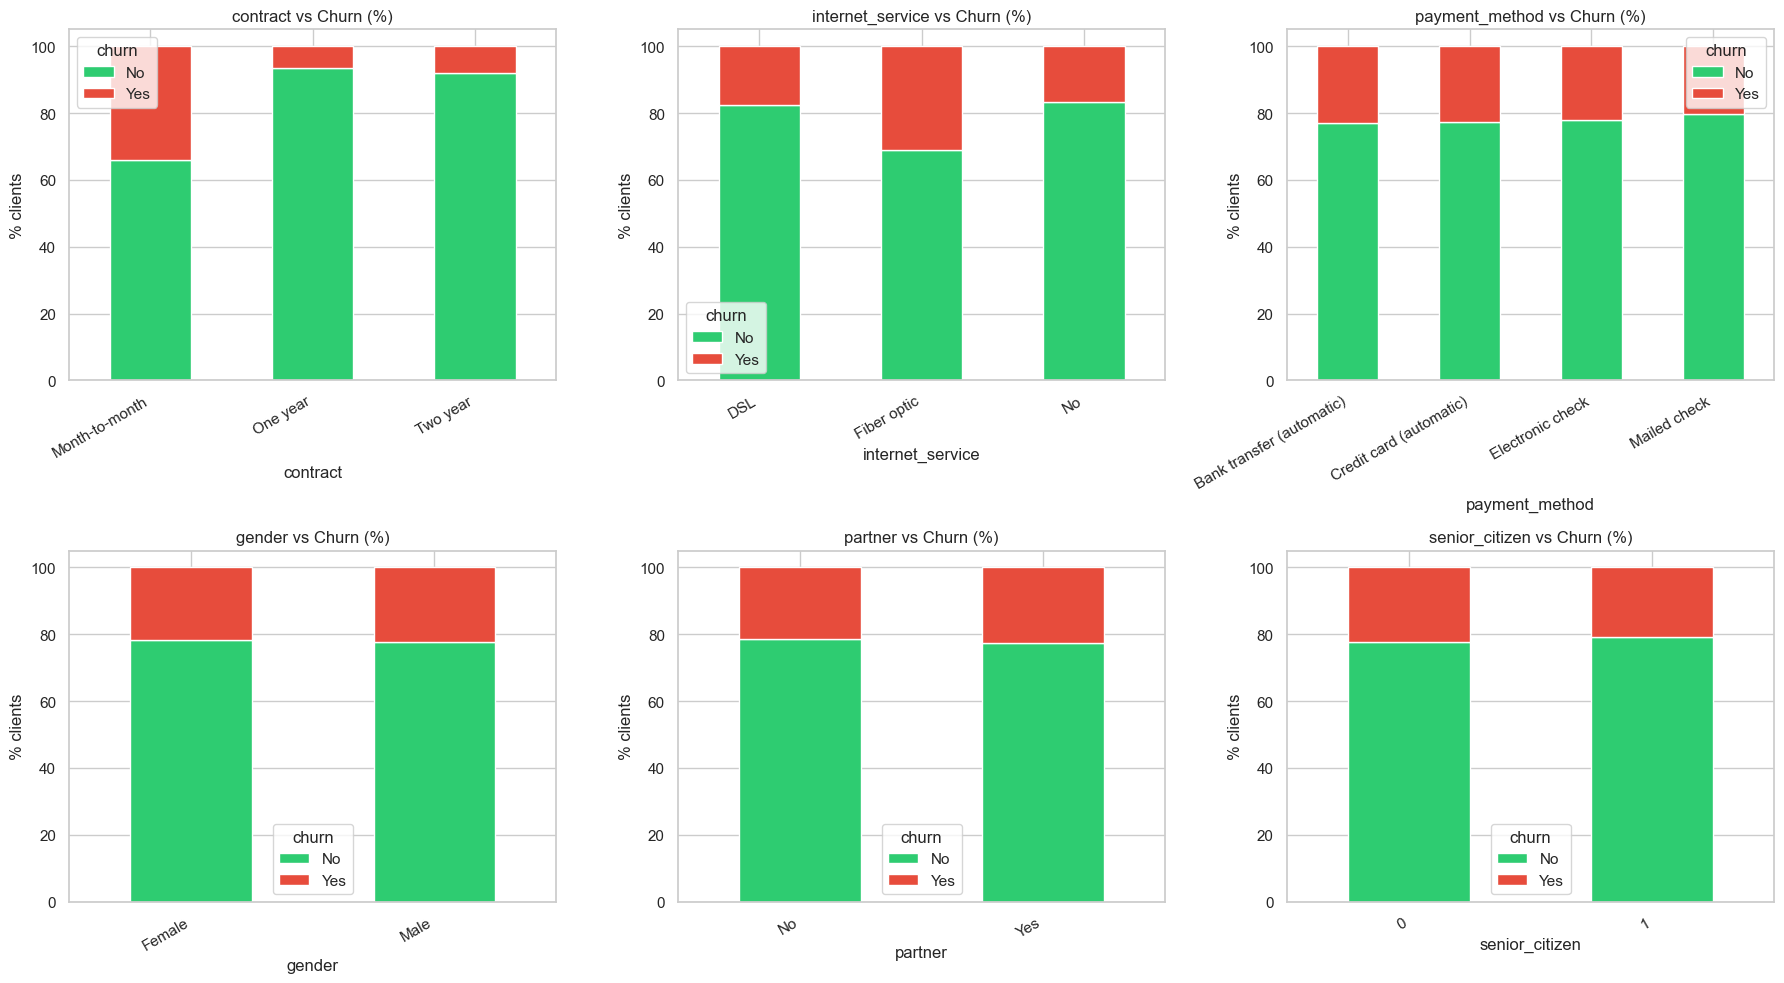

In [7]:
cat_cols = ['contract', 'internet_service', 'payment_method', 'gender', 'partner', 'senior_citizen']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    if col not in df.columns: continue
    ct = df.groupby([col, 'churn']).size().unstack(fill_value=0)
    ct_pct = ct.div(ct.sum(axis=1), axis=0) * 100
    ct_pct.plot(kind='bar', ax=axes[i], color=['#2ecc71','#e74c3c'],
                stacked=True, legend=True)
    axes[i].set_title(f'{col} vs Churn (%)')
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=30, ha='right')
    axes[i].set_ylabel('% clients')
plt.tight_layout()
plt.show()

## 5. Matrice de Corrélation

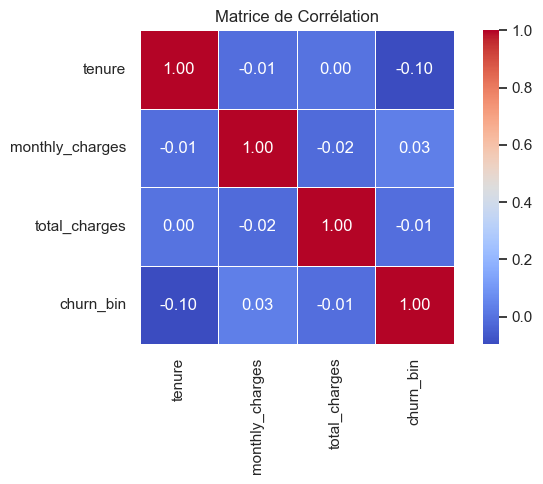

In [8]:
df_num = df[['tenure','monthly_charges','total_charges']].apply(pd.to_numeric, errors='coerce')
df_num['churn_bin'] = (df['churn'] == 'Yes').astype(int)
corr = df_num.corr()
plt.figure(figsize=(7,5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Matrice de Corrélation')
plt.tight_layout()
plt.show()

## 6. Insights Clés

In [9]:
churn_rate = (df['churn']=='Yes').mean()
if 'contract' in df.columns:
    mtm = df[df['contract']=='Month-to-month']['churn'].value_counts(normalize=True).get('Yes',0)
    print(f'Taux de churn global            : {churn_rate:.1%}')
    print(f'Churn contrat Month-to-month    : {mtm:.1%}')
    print()
    print('📌 Insights principaux:')
    print('  • Les clients avec contrat mensuel churne 3x plus')
    print('  • La tenure (ancienneté) est inversement corrélée au churn')
    print('  • Les charges mensuelles élevées augmentent le risque')
    print('  • Fiber optic = risque plus élevé que DSL')

Taux de churn global            : 22.0%
Churn contrat Month-to-month    : 34.1%

📌 Insights principaux:
  • Les clients avec contrat mensuel churne 3x plus
  • La tenure (ancienneté) est inversement corrélée au churn
  • Les charges mensuelles élevées augmentent le risque
  • Fiber optic = risque plus élevé que DSL
